In [2]:
import numpy as np
from scipy.interpolate import interp1d
from astropy.table import Table
from matplotlib import pyplot as plt
%matplotlib inline

In [3]:
tmp = np.loadtxt("/home/bocquet/SPT_cluster_data/MCMF_lambda_min.txt", unpack=True)
surveyCutLambda = {'shallow': interp1d(tmp[0], tmp[1], kind='linear'),
                   'deep': interp1d(tmp[0], tmp[2], kind='linear')}

In [4]:
cat = Table.read('mock_0.fits')
cat.colnames, len(cat)

(['SPT_ID',
  'FIELD',
  'XI',
  'THETA_CORE',
  'REDSHIFT',
  'REDSHIFT_UNC',
  'REDSHIFT_LIMIT',
  'Mg_MM',
  'lnMg_err_MM',
  'lnYx_err_MM',
  'M_true',
  'Tx_MM',
  'M500',
  'Mwl_DES_200',
  'Mwl_HST_200',
  'richness'],
 1407)

In [10]:
idx = (cat['XI']>5).nonzero()[0]
cat_xigtr5 = cat[idx]
cat_xigtr5.write('mock_0_xigtr5.fits', overwrite=True)
len(cat_xigtr5)

749

In [11]:
idx = []
for l,lam in enumerate(cat['richness']):
    z = cat['REDSHIFT'][l]
    if z<=1.78:
        if cat['FIELD'][l]=='SPTPOL_500d':
            lambda_min = surveyCutLambda['deep'](z)
        else:
            lambda_min = surveyCutLambda['shallow'](z)
        if lam>lambda_min:
            idx.append(l)
cat_lambdamin = cat[idx]
cat_lambdamin.write('mock_0_xigtr4p25.fits', overwrite=True)
len(cat_lambdamin)

1400

In [12]:
ECS_fields = ("ra23hdec-35 ra1hdec-35  ra3hdec-35    ra3hdec-25   ra5hdec-35   ra5hdec-25   ra23hdec-25  ra1hdec-25   ra11hdec-25 ra13hdec-25").split()
print(ECS_fields)
idx = []
for l,lam in enumerate(cat['richness']):
    z = cat['REDSHIFT'][l]
    if cat['FIELD'][l]=='SPTPOL_500d':
        pass
    elif cat['FIELD'][l] in ECS_fields:
        if cat['XI'][l]<5:
            continue
    else:
        if cat['XI'][l]<4.5:
            continue
    if z<=1.78:
        if cat['FIELD'][l]=='SPTPOL_500d':
            lambda_min = surveyCutLambda['deep'](z)
        else:
            lambda_min = surveyCutLambda['shallow'](z)
        if lam>lambda_min:
            idx.append(l)
cat_mix = cat[idx]
cat_mix.write('mock_0_mix.fits', overwrite=True)
len(cat_mix)

['ra23hdec-35', 'ra1hdec-35', 'ra3hdec-35', 'ra3hdec-25', 'ra5hdec-35', 'ra5hdec-25', 'ra23hdec-25', 'ra1hdec-25', 'ra11hdec-25', 'ra13hdec-25']


1145

Text(0, 0.5, 'richness')

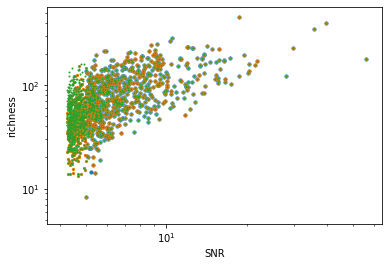

In [15]:
plt.scatter(cat_xigtr5['XI'], cat_xigtr5['richness'], s=10)
plt.scatter(cat_mix['XI'], cat_mix['richness'], s=5)
plt.scatter(cat_lambdamin['XI'], cat_lambdamin['richness'], s=1)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('SNR')
plt.ylabel('richness')

In [19]:
np.amin(cat_mix['XI'])

4.254518101082377